Students are often introduced to the Monte Carlo simulation via its application in the approximation of $\pi$. Indeed, as we will see below, if one constructs a unit square with an inscribed circle whose diameter is the length of the side of the square, one can run such a simulation to approximate $\pi$. However, usually the investigation stops there and one moves on to more "useful" applications of the Monte Carlo simulation.

The following is a brief dive into two questions that arise from the nature of the inputs of the Monte Carlo simulation. The simulation to approximate $\pi$ has two independent variables: 

* The number of samples taken in the simulation which we will call "runs," and
* the number of random variables, also known as the dimension.

The following will give the derivation of the approximation of $\pi$ in 2D space, and all else being equal, we will generalize this to 3 dimensions. Then we will investigate the aforementioned questions.

Hence, consider the following. The figure below has two shapes concentric at (0,0), a unit square and an inscribed circle whose diameter is the length of the side of the square. We assert that we can approximate $\pi$ by finding the ratio of the area of the circle relative to the square and multiplying by 4. 

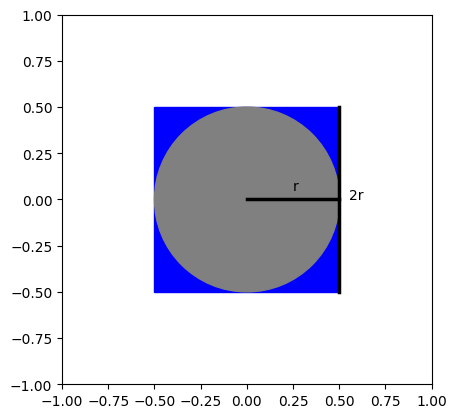

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
fig, ax = plt.subplots()
circle = patches.Circle((0, 0), radius=0.5, color='grey')
square = patches.Rectangle((-0.5, -0.5), width=1, height=1, color='blue')
ax.add_patch(square)
ax.add_patch(circle)
plt.plot([0, 0.5], [0, 0], color='black', linewidth=2.5)
plt.plot([0.5, 0.5], [-0.5, 0.5], color='black', linewidth=2.5)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.text(0.25, 0.05, "r")
ax.text(0.55, 0, "2r")
ax.set_aspect('equal')
plt.show()

Now, the area $A_{c}$ of a circle whose radius is $r$ is given by the equation

$$A_{c} = \pi r^2$$

Since the side length of the containing square is $2r$, the area $A_{s}$ of the square is

$$A_{s} = 4r^2$$

Taking the ratio of these two areas we get

$$\frac{A_{c}}{A_{s}} = \frac{\pi r^2}{4r^2} = \frac{\pi}{4}$$

Thus, $$\pi = 4 \cdot \frac{A_{c}}{A_{s}}$$ as asserted.

Using a Monte Carlo simulation we can approximate this ratio to give an approximation of $\pi$. Mathematically, we will randomly sample a uniform distribution across the containing square a given number of times, say 100,000 runs. We will then calculate how many samples land inside our circle verus the total number of samples within the square. Multiplying this sample ratio by 4 will give us the approximation of $\pi$.

Conceptually, we can think of this as randomly throwing 100,000 darts at a square dartboard and comparing the number of darts that land on the inscribed circle versus the total number of darts that land on the dartboard.

From here, we will model the square as a Cartesian grid centered at $(0,0)$ and randomly sample the random variables $x$ and $y$. Then we will determine the ratio of points in the circle versus total points in the square, which will be our approximation of the ratio of areas.

In [2]:
import numpy as np

def simulate_hypersphere_ratio(dimensions: int, runs: int = 100000, seed: int = 42) -> float:
    rng = np.random.default_rng(seed=seed)
    
    # Generate samples across dimensions
    samples = rng.uniform(-0.5, 0.5, size=(runs, dimensions))
    
    # Calculate square distance for every point
    distances_squared = np.sum(np.square(samples), axis=1)
    
    # Count how many samples fall inside circle (or hypersphere, generally)
    inside_sphere = np.sum(distances_squared <= 0.5**2)
    
    # Return volume ratio
    return inside_sphere / runs, samples

The graph below shows the 100,000 sample points on the unit square. As can be seen, the grey points are the points that lie within the circle. Taking the ratio of these points to the total number of grey and blue points, and then multiplying this figure by four results in our approximation of $\pi$. Here, we get a figure of 3.1354. Not too far from the true of $\pi$, which is roughly 3.14159.

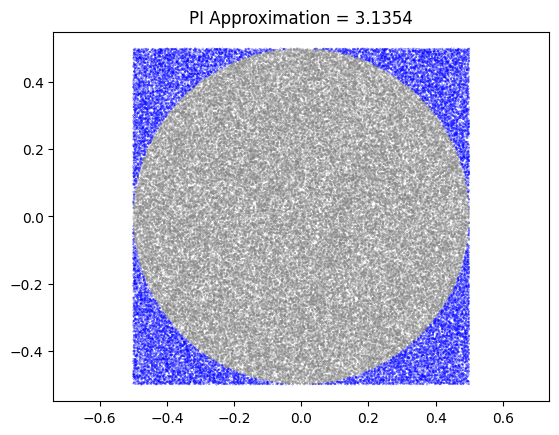

In [3]:
ratio, samples = simulate_hypersphere_ratio(dimensions=2)
mcPI = ratio * 4

x = samples[:, 0]
y = samples[:, 1]

inCircle = (x**2 + y**2 <= 0.5**2)

circle = np.where(inCircle == True, 'grey', 'blue')
plt.scatter(x, y, s=0.025, c=circle)
plt.title(f"PI Approximation = {mcPI}")
plt.axis('equal');

Observe that the results above are dependent on the the number of runs and the dimension. Thus, it is natural to ask two questions: 

* What happens if we change the number of random samples taken?
* Does the approximation for $\pi$ hold in higher dimensions?

These will be addressed in turn.

In a Monte Carlo simulation, changing the number of samples is equivalent is changing the number of runs. Indeed, 100,000 is no special number. One could easily choose, say, 1,000,000 runs. The only true limits are computational. i.e. attempting one billion runs with insufficient computational resources may either crash the computer or take so long as to be infeasible. Nonetheless, suppose we choose 1,000,000.

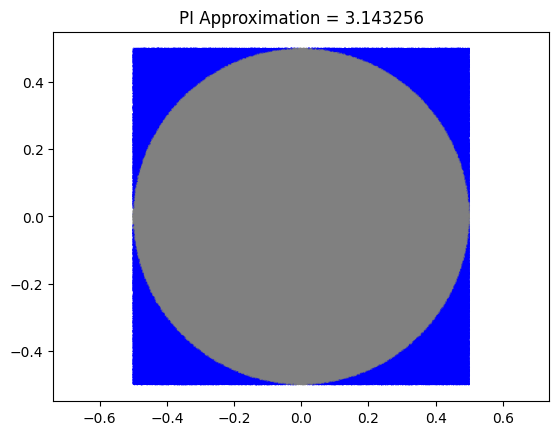

In [4]:
ratio, samples = simulate_hypersphere_ratio(dimensions=2, runs=1000000)
mcPI = ratio * 4

x = samples[:, 0]
y = samples[:, 1]

inCircle = (x**2 + y**2 <= 0.5**2)

circle = np.where(inCircle == True, 'grey', 'blue')
plt.scatter(x, y, s=0.025, c=circle)
plt.title(f"PI Approximation = {mcPI}")
plt.axis('equal');

The figure above shows the results if we hold everything equal but run the simulation 1,000,000 times. Visually, the points cover much more of the square. But notice the figure for $\pi$. It is now 3.143256. Even closer to the true value of 3.14159! Indeed, a general rule of thumb is that we can expect to more closely approximate $\pi$ given an increasing number of runs.

So, we've addressed the first question. Now, let's move to higher dimensions. The natural progression from here would be to investigate what happens in three dimensions.

First, we need to find the equivalent of the ratio of areas that we used previously. That is, we will be using the ratio of volumes of a unit sphere and unit cube. Now, the volume $V_{s}$ of a sphere with radius $r$ is given by the equation
$$V_{s} = \frac{4}{3} \pi r^{3}$$
And the volume $V_{c}$ of a cube with side length $2r$ is 
$$V_{c} = (2r)^{3} = 8r^{3}$$ 
Taking the ratio we get
$$\frac{V_{s}}{V_{c}} = \frac{\frac{4}{3} \pi r^{3}}{8r^{3}} = \frac{\pi}{6}$$

Thus, if we can approximate the ratio of volumes and multiply this ratio by 6, we will be again obtain an apporoximation of $\pi$. Hence, we will run a monte carlo simulation with 100,000 runs and three random variables $x, y, z$.

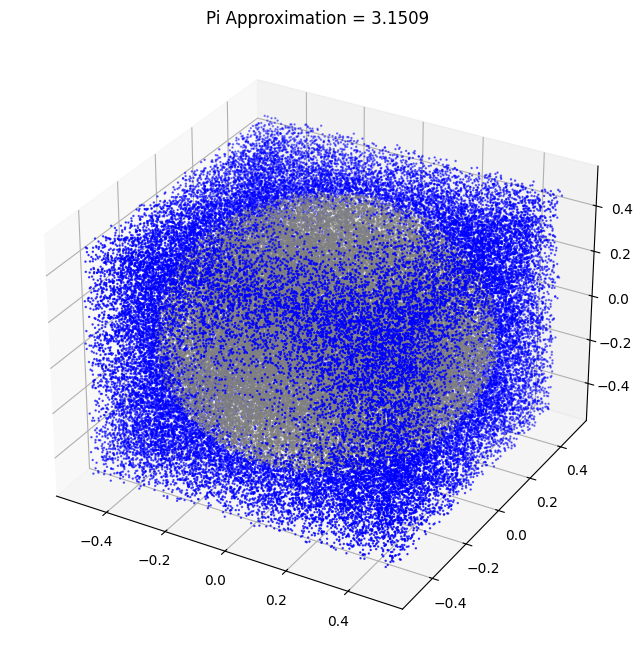

In [5]:
ratio, samples = simulate_hypersphere_ratio(dimensions=3)
mcPI = ratio * 6

x = samples[:, 0]
y = samples[:, 1]
z = samples[:, 2]

inSphere = x**2 + y**2 + z**2 <= 0.5**2

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
sphere = np.where(inSphere == True, 'grey', 'blue')
ax.scatter(x, y, z, s=0.5, c=sphere)
plt.title(f'Pi Approximation = {mcPI}');

The figure above illustrates the results. We've essentialy dropped a bunch of points into the containing cube and observed how many landed in the sphere. As in the 2D case, we obtain a somewhat close approximation of 3.1509. But, all else being equal, this is certainly further from the true value than the approximation from the 2D case. This suggests that increasing dimensions might reduce our accuracy. 

Visualization is naturally limited to three dimensions. So, we will be unable to create a figure as in the lower dimensions. However, this limitation does not bound us algebraically in higher dimensions.

An $n$-hypersphere is a generalization of the circle into $n$ dimensions, where $n$ is a positive integer. It is often called an $n$-sphere. i.e. a circle is a $2$-sphere and a sphere is a $3$-sphere. The equation for the volume $V_{s,n}(r)$ of a $n$-sphere with radius $r$ is

$$V_{s,n}(r) = \frac{\pi^{n/2}}{\Gamma\left(\frac{n}{2} + 1\right)} r^n$$

where $\Gamma$ is the gamma function (which is a generalization of the factorial to the complex and real numbers). Since we are concerned with $n$-spheres of radius 1, we have

$$V_{s,n}(1) = \frac{\pi^{n/2}}{\Gamma\left(\frac{n}{2} + 1\right)}$$

Similarly, the $n$-hypercube ($n$-cube) enclosing the hypersphere has side length $2r$ and volume $V_{c,n}(2r)$ given by 

$$V_{c,n}(2r) = (2r)^{n} = 2^{n}r^{n}$$

And since our sphere has radius one, we have 

$$V_{c,n}(2) = 2^{n}$$

Thus for any positive integer n, we can express the ratio of the unit hypersphere to its concentric enclosing hypercube as

$$\frac{V_{s,n}(1)}{V_{c,n}(2)} \\
= \frac{\frac{\pi^{n/2}}{\Gamma\left(\frac{n}{2} + 1\right)}}{2^{n}} \\
= \frac{\pi^{n/2}}{2^{n}\Gamma\left(\frac{n}{2} + 1\right)}$$


Now, let's investigate what happens for the first ten positive integers. The following table illustrates the results.

| n | $\frac{V_{s,n}(1)}{V_{c,n}(2)}$ | Relative hypersphere volume (%) |
| :-: | :-------------------------------: | :-------------------------: |
| 1 | 1 | $100\%$ |
| 2 | $\frac{\pi}{4}$ | $78.5\%$ |
| 3 | $\frac{\pi}{6}$ | $52.4\%$ |
| 4 | $\frac{\pi^{2}}{32}$ | $30.8\%$ |
| 5 | $\frac{\pi^{2}}{60}$ | $16.5\%$ |
| 6 | $\frac{\pi^{3}}{384}$ | $8.1\%$ |
| 7 | $\frac{\pi^{3}}{840}$ | $3.7\%$ |
| 8 | $\frac{\pi^{4}}{6144}$ | $1.6\%$ |
| 9 | $\frac{\pi^{4}}{15120}$ | $0.65\%$ |
| 10 | $\frac{\pi^{5}}{122880}$ | $0.25\%$ |

Aha! The third column tells the story. As the dimensions grow, the volume of the hypersphere relative to the volume of the enclosing hypercube shrinks drastically, to the point that, even in just ten dimensions, the sphere becomes minuscule in comparison. In effect, the "corners" of the cube essentially dominate the total volume of the cube, with the sphere itself contributing an increasingly smaller amounts of the overall volume. Thus, our question is answered without the additional tedium of providing an actual approximation of $\pi$ in, say, ten dimensions. Indeed, performing such a Monte Carlo simulation, as was done for the 2D and 3D cases, would prove to be of little use. We would essentially be throwing 100,000 darts at a dartboard the size of a (square) football field, attempting to figure out the ratio of how many hit a target the size of quarter (roughly speaking).